In [1]:
import pandas as pd
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
dir = Path("/home/py/groundwater/data/gown/raw/active")

In [3]:
banff = pd.read_csv('/home/py/groundwater/data/bow_valley/stream/Stage.Working@05BB001.20110101_corrected.csv', skiprows=14, usecols=[1, 2], parse_dates=[0], index_col=0).squeeze()
banff = banff+1376.388
banff = banff.resample('h').mean()

In [4]:
wells = ['0760', '0759', '0764', '0364'] 

In [5]:
well_dfs = {}

for well in wells:
    with zipfile.ZipFile(dir / f'{well}.zip', 'r') as z:
        well_dfs[well] = pd.read_csv(z.open("tsvalues.csv"), skiprows=9, sep=';', usecols=[0,2], parse_dates=[0], index_col=0).squeeze()
        well_dfs[well].index = well_dfs[well].index.tz_localize(None)

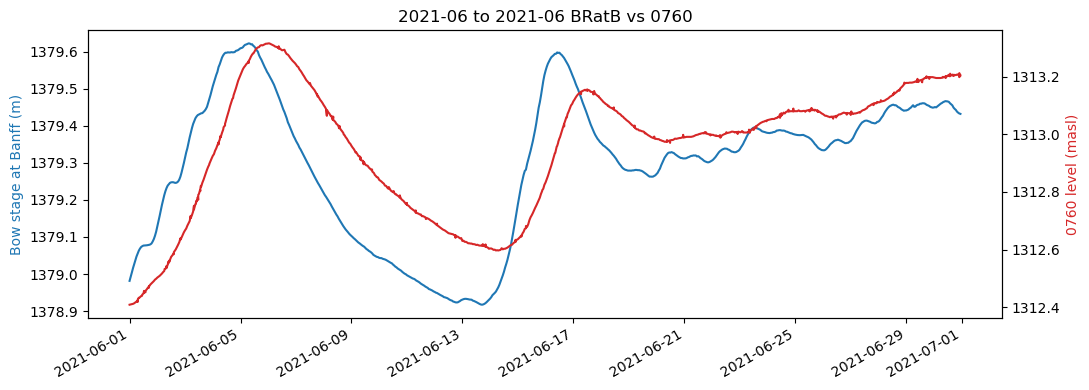

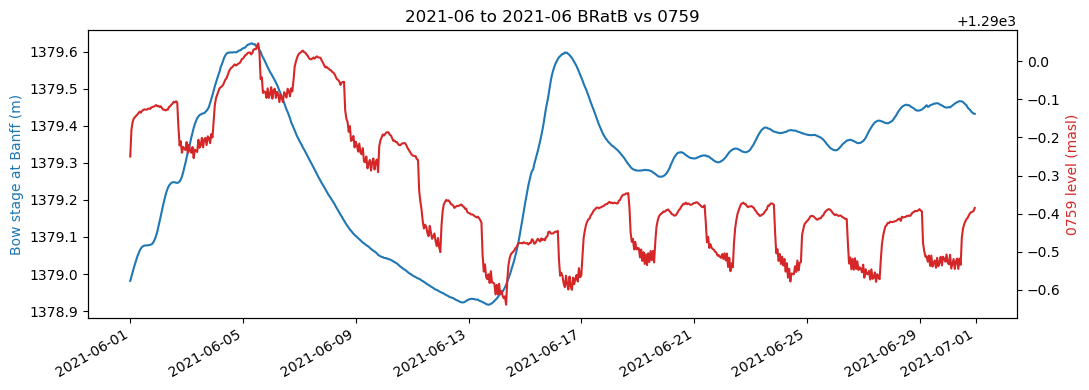

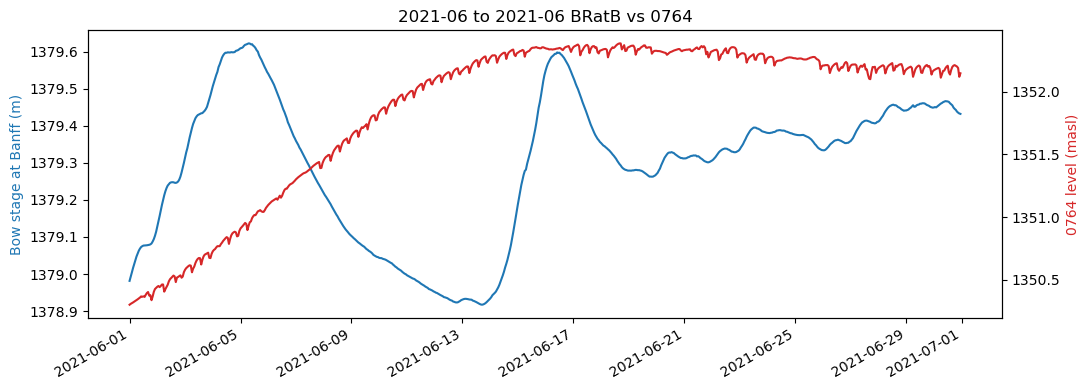

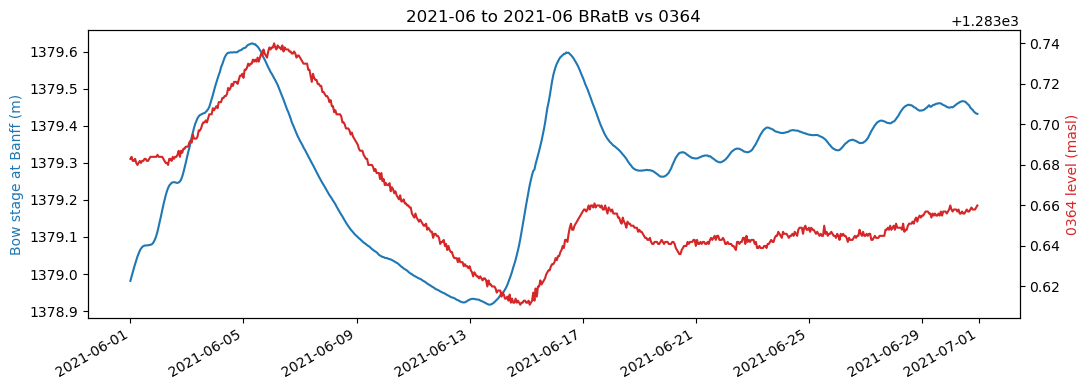

In [16]:
range = ("2021-06", "2021-06")

for well, df in well_dfs.items():
    fig, ax = plt.subplots(figsize=(11, 4))

    ax.plot(banff.loc[range[0]:range[1]].index, banff.loc[range[0]:range[1]], "tab:blue")
    ax.set_ylabel("Bow stage at Banff (m)", color="tab:blue")

    a2 = ax.twinx()
    a2.plot(df.loc[range[0]:range[1]].index, df.loc[range[0]:range[1]], "tab:red")
    a2.set_ylabel(f"{well} level (masl)", color="tab:red")

    ax.set_title(f"{range[0]} to {range[1]} BRatB vs {well}")

    fig.autofmt_xdate()
    fig.tight_layout()

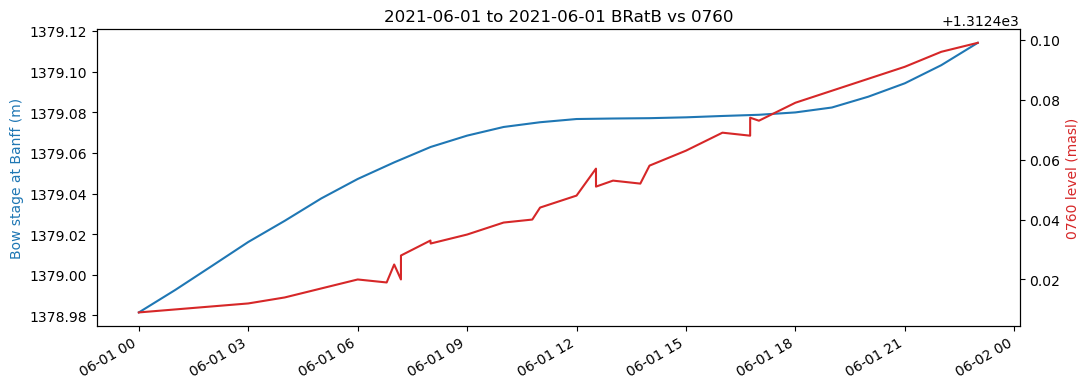

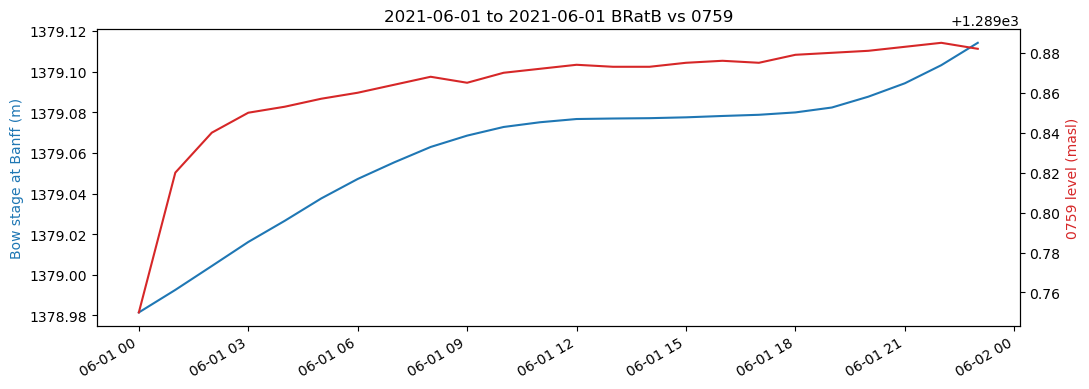

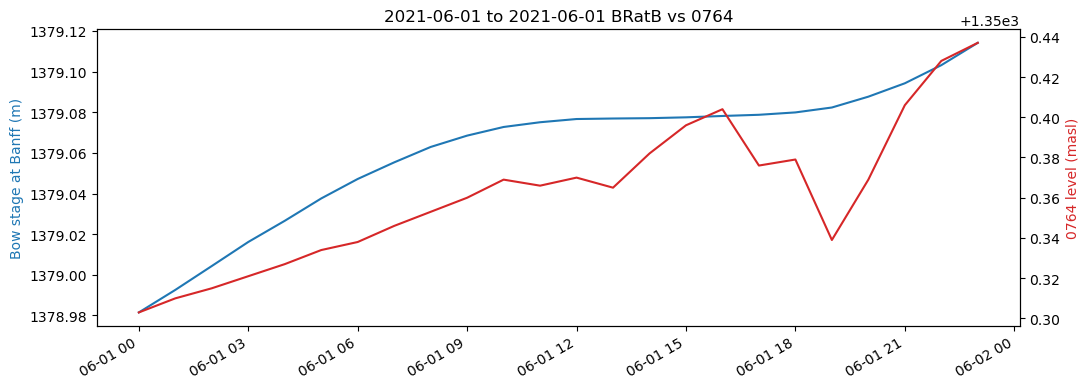

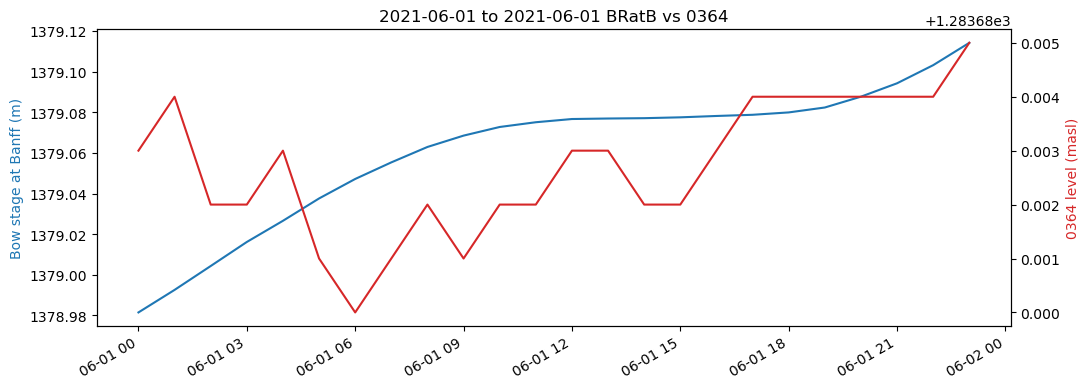

In [17]:
range = ("2021-06-01", "2021-06-01")

for well, df in well_dfs.items():
    fig, ax = plt.subplots(figsize=(11, 4))

    ax.plot(banff.loc[range[0]:range[1]].index, banff.loc[range[0]:range[1]], "tab:blue")
    ax.set_ylabel("Bow stage at Banff (m)", color="tab:blue")

    a2 = ax.twinx()
    a2.plot(df.loc[range[0]:range[1]].index, df.loc[range[0]:range[1]], "tab:red")
    a2.set_ylabel(f"{well} level (masl)", color="tab:red")

    ax.set_title(f"{range[0]} to {range[1]} BRatB vs {well}")

    fig.autofmt_xdate()
    fig.tight_layout()